<img src="./logo_UNSAM.jpg" align="right" width="250" />  -->
# Análisis y Procesamiento de Señales

## Trabajo Práctico Nº4
#### Sofía Gervasi


# Introducción

Este estudio se centra en la evaluación del desempeño de estimadores espectrales aplicados a una señal sinusoidal, con el objetivo específico de determinar la precisión en la estimación de su amplitud $ a_1 $ y frecuencia $ Ω_1 $. Para ello, se comparará el comportamiento de dichos estimadores, implementando diferentes ventanas de análisis (Rectangular, Flattop, Blackman-Harris y Hann), y variando la relación señal a ruido (SNR). El análisis se enfocará en cuantificar el sesgo y la varianza de cada estimador bajo las condiciones experimentales propuestas, permitiendo así una evaluación comparativa de su eficacia.

Se propone para una señal

$$ x(n) = a_1 \cdot \text{sen}(\Omega_1 \cdot n) + n_a(n) $$ 

$$ \Omega_1 = \frac{\pi}{2}  + f_r \cdot \frac{2\pi}{N} $$

y las variables aleatorias definidas por

$$ f_r \sim U\left(-\frac{1}{2}, \frac{1}{2}\right) $$

$$ n_a \sim N(0, \sigma^2) $$


evaluar los siguientes estimadores de $ a_1 $ y $ Ω_1 $

$$ \hat{a}_{1i} = |X_i^w(\Omega_0)| = |F{x(n) \cdot w_i(n)}| $$

$$ \hat{\Omega}{1i} = \arg \max{f} { |X_i^w(\Omega)| } $$


## I. Parametrización para SNR de 10dB

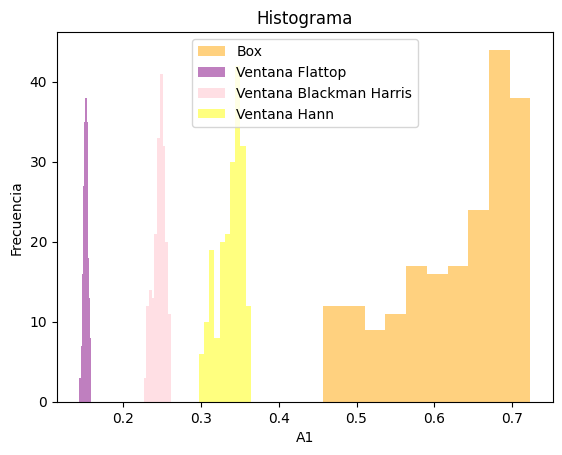

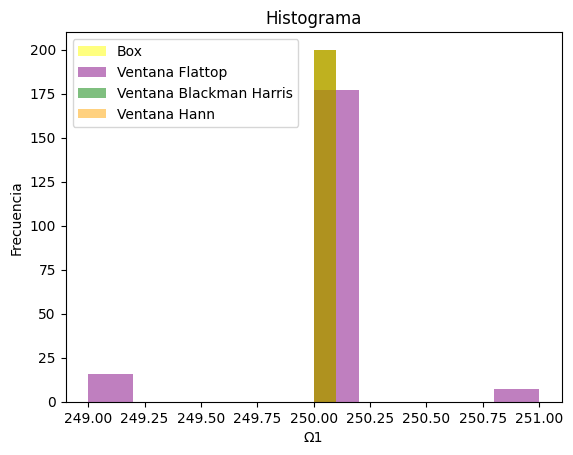

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Thu Apr  3 20:36:49 2025

@author: Sofía
"""
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# Datos de la simulación

fs = 1000 # frecuencia de muestreo (Hz)
N = 1000 # cantidad de muestras
ts = 1/fs  # tiempo de muestreo
df =fs/N  # resolución espectral


R=200 # Numero de pruebas

#Generación de Señal

tt = np.linspace(0, (N-1)*ts, N).reshape((N,1)) # Vector columna de [N, 1]
vtt=np.tile(tt, (1,R)) #vector columna de [N, R]

f0=fs/4 #mitad de franja digital
fr=np.random.uniform(-1/2,1/2,size=(1,R)) #Vector flat de [1, R]
f1=f0+fr*df

aa= np.sqrt(2)
xk = aa*np.sin(2*np.pi*f1*vtt) 

#Generación del ruido
SNR=10
Pnk=10**(-SNR/10) #Potencia del Ruido
sigma=np.sqrt(Pnk)
nk=np.random.normal(0,sigma,(N,R))

#%% FFT
S=xk+nk #[N,R]

S_fft = np.fft.fft(S, axis=0) / N
ffx = np.linspace(0, (N-1)*df, N)
bfrec = ffx <= fs/2

# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(S_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro de la señal')
# plt.grid(True)
# plt.show()

#%% Ventana Flattop
wf=signal.windows.flattop(N).reshape((N,1)) #matriz [N,1]
xwf=S*wf

xwf_fft = np.fft.fft(xwf, axis=0) / N


# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(xwf_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro Ventaneado con Flattop')
# plt.grid(True)
# plt.show()

#%% Ventana Blackman Harris
wb=signal.windows.blackmanharris(N).reshape((N,1)) 
xwb=S*wb

xwb_fft = np.fft.fft(xwb, axis=0) / N


# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(xwb_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro Ventaneado con Blackman Harris')
# plt.grid(True)
# plt.show()

#%% Ventana Hann
wh=signal.windows.hann(N).reshape((N,1)) 
xwh=S*wh

xwh_fft = np.fft.fft(xwh, axis=0) / N

# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(xwh_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro Ventaneado con Hann')
# plt.grid(True)
# plt.show()

#%% Busco los a1 de cada ventana para la frec N/4

vs=np.abs(S_fft[250,:]) # Frec N/4 de la FFT
vf=np.abs(xwf_fft[250,:]) # Frec N/4 de la ventana Flattop
vb=np.abs(xwb_fft[250,:]) #Frec N/4 de la ventana Blackman Harris
vh=np.abs(xwh_fft[250,:]) #Frec N/4 de la ventana Hann

plt.figure()
plt.hist(vs, bins=10, color='orange', alpha=0.5, label='Box')
plt.hist(vf, bins=10, color='purple', alpha=0.5, label='Ventana Flattop')
plt.hist(vb, bins=10, color='pink', alpha=0.5, label='Ventana Blackman Harris')
plt.hist(vh, bins=10, color='yellow', alpha=0.5, label='Ventana Hann')


plt.title('Histograma')
plt.xlabel('A1')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#%%Calculo de la Varianza y el Sesgo de a1
sesgo_a1_box=np.mean(vs-aa)
sesgo_a1_f=np.mean(vf-aa)
sesgo_a1_bh=np.mean(vb-aa)
sesgo_a1_h=np.mean(vh-aa)

varianza_a1_box=np.var(vs-aa)
varianza_a1_f=np.var(vf-aa)
varianza_a1_bh=np.var(vb-aa)
varianza_a1_h=np.var(vh-aa)

# i_box=np.mean(vs-sesgo_a1_box-aa)
# i_f=np.mean(vf-sesgo_a1_box-aa)
# i_bh=np.mean(vb-sesgo_a1_box-aa)
# i_h=np.mean(vh-sesgo_a1_box-aa)

#%% Estimador Ω1

arg_vs=np.argmax((1/N)*np.abs(S_fft[bfrec,:])**2,axis=0)
arg_vf=np.argmax((1/N)*np.abs(xwf_fft[bfrec,:])**2,axis=0)
arg_vb=np.argmax((1/N)*np.abs(xwb_fft[bfrec,:])**2,axis=0)
arg_vh=np.argmax((1/N)*np.abs(xwh_fft[bfrec,:])**2,axis=0)

omega_vs=arg_vs*df
omega_vf=arg_vf*df
omega_vb=arg_vb*df
omega_vh=arg_vh*df

plt.figure()
plt.hist(omega_vs, bins=10, color='yellow', alpha=0.5, label='Box')
plt.hist(omega_vf, bins=10, color='purple', alpha=0.5, label='Ventana Flattop')
plt.hist(omega_vb, bins=10, color='green', alpha=0.5, label='Ventana Blackman Harris')
plt.hist(omega_vh, bins=10, color='orange', alpha=0.5, label='Ventana Hann')

plt.title('Histograma')
plt.xlabel('Ω1')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#%%Calculo de la Varianza y el Sesgo de Ω1
sesgo_o1_box=np.mean(omega_vs-f1)
sesgo_o1_f=np.mean(omega_vf-f1)
sesgo_o1_bh=np.mean(omega_vb-f1)
sesgo_o1_h=np.mean(omega_vh-f1)

varianza_o1_box=np.var(omega_vs-f1)
varianza_o1_f=np.var(omega_vf-f1)
varianza_o1_bh=np.var(omega_vb-f1)
varianza_o1_h=np.var(omega_vh-f1)

## II. Parametrización para SNR de 3dB

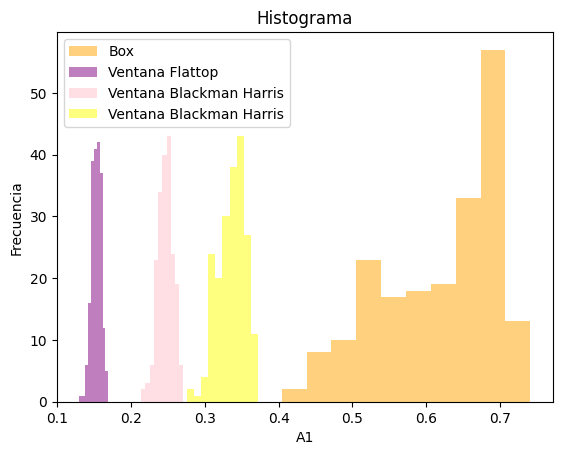

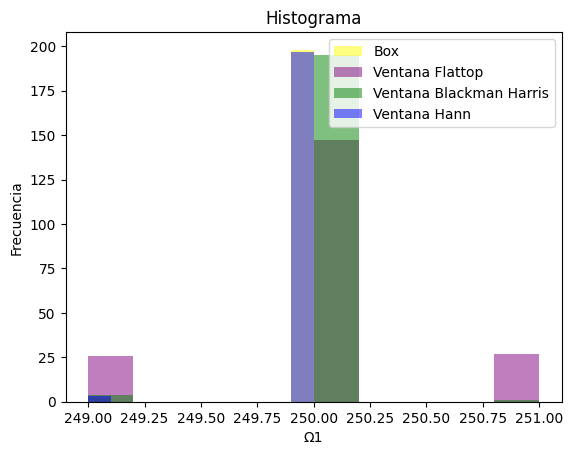

In [7]:
# -*- coding: utf-8 -*-
"""
Created on Thu Apr  3 20:36:49 2025

@author: Sofía
"""
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# Datos de la simulación

fs = 1000 # frecuencia de muestreo (Hz)
N = 1000 # cantidad de muestras
ts = 1/fs  # tiempo de muestreo
df =fs/N  # resolución espectral


R=200 # Numero de pruebas

#Generación de Señal

tt = np.linspace(0, (N-1)*ts, N).reshape((N,1)) # Vector columna de [N, 1]
vtt=np.tile(tt, (1,R)) #vector columna de [N, R]

f0=fs/4 #mitad de franja digital
fr=np.random.uniform(-1/2,1/2,size=(1,R)) #Vector flat de [1, R]
f1=f0+fr*df

aa= np.sqrt(2)
xk = aa*np.sin(2*np.pi*f1*vtt) 

#Generación del ruido
SNR=3
Pnk=10**(-SNR/10) #Potencia del Ruido
sigma=np.sqrt(Pnk)
nk=np.random.normal(0,sigma,(N,R))

#%% FFT
S=xk+nk #[N,R]

S_fft = np.fft.fft(S, axis=0) / N
ffx = np.linspace(0, (N-1)*df, N)
bfrec = ffx <= fs/2

# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(S_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro de la señal')
# plt.grid(True)
# plt.show()

#%% Ventana Flattop
wf=signal.windows.flattop(N).reshape((N,1)) #matriz [N,1]
xwf=S*wf

xwf_fft = np.fft.fft(xwf, axis=0) / N


# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(xwf_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro Ventaneado con Flattop')
# plt.grid(True)
# plt.show()

#%% Ventana Blackman Harris
wb=signal.windows.blackmanharris(N).reshape((N,1)) 
xwb=S*wb

xwb_fft = np.fft.fft(xwb, axis=0) / N


# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(xwb_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro Ventaneado con Blackman Harris')
# plt.grid(True)
# plt.show()

#%% Ventana Hann
wh=signal.windows.hann(N).reshape((N,1)) 
xwh=S*wh

xwh_fft = np.fft.fft(xwh, axis=0) / N

# plt.figure()
# for i in range(R):
#     plt.plot(ffx[bfrec], 10 * np.log10(2 * np.abs(xwh_fft[bfrec, i]) ** 2))

# plt.xlabel('Frecuencia (Hz)')
# plt.ylabel('Densidad de Potencia (dB)')
# plt.title('Espectro Ventaneado con Hann')
# plt.grid(True)
# plt.show()

#%% Busco los a1 de cada ventana para la frec N/4

vs=np.abs(S_fft[250,:]) # Frec N/4 de la FFT
vf=np.abs(xwf_fft[250,:]) # Frec N/4 de la ventana Flattop
vb=np.abs(xwb_fft[250,:]) #Frec N/4 de la ventana Blackman Harris
vh=np.abs(xwh_fft[250,:]) #Frec N/4 de la ventana Hann

plt.figure()
plt.hist(vs, bins=10, color='orange', alpha=0.5, label='Box')
plt.hist(vf, bins=10, color='purple', alpha=0.5, label='Ventana Flattop')
plt.hist(vb, bins=10, color='pink', alpha=0.5, label='Ventana Blackman Harris')
plt.hist(vh, bins=10, color='yellow', alpha=0.5, label='Ventana Blackman Harris')


plt.title('Histograma')
plt.xlabel('A1')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#%%Calculo de la Varianza y el Sesgo de a1
sesgo_a1_box=np.mean(vs-aa)
sesgo_a1_f=np.mean(vf-aa)
sesgo_a1_bh=np.mean(vb-aa)
sesgo_a1_h=np.mean(vh-aa)

varianza_a1_box=np.var(vs-aa)
varianza_a1_f=np.var(vf-aa)
varianza_a1_bh=np.var(vb-aa)
varianza_a1_h=np.var(vh-aa)

# i_box=np.mean(vs-sesgo_a1_box-aa)
# i_f=np.mean(vf-sesgo_a1_box-aa)
# i_bh=np.mean(vb-sesgo_a1_box-aa)
# i_h=np.mean(vh-sesgo_a1_box-aa)

#%% Estimador Ω1

arg_vs=np.argmax((1/N)*np.abs(S_fft[bfrec,:])**2,axis=0)
arg_vf=np.argmax((1/N)*np.abs(xwf_fft[bfrec,:])**2,axis=0)
arg_vb=np.argmax((1/N)*np.abs(xwb_fft[bfrec,:])**2,axis=0)
arg_vh=np.argmax((1/N)*np.abs(xwh_fft[bfrec,:])**2,axis=0)

omega_vs=arg_vs*df
omega_vf=arg_vf*df
omega_vb=arg_vb*df
omega_vh=arg_vh*df

plt.figure()
plt.hist(omega_vs, bins=10, color='yellow', alpha=0.5, label='Box')
plt.hist(omega_vf, bins=10, color='purple', alpha=0.5, label='Ventana Flattop')
plt.hist(omega_vb, bins=10, color='green', alpha=0.5, label='Ventana Blackman Harris')
plt.hist(omega_vh, bins=10, color='blue', alpha=0.5, label='Ventana Hann')

plt.title('Histograma')
plt.xlabel('Ω1')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#%%Calculo de la Varianza y el Sesgo de Ω1
sesgo_o1_box=np.mean(omega_vs-f1)
sesgo_o1_f=np.mean(omega_vf-f1)
sesgo_o1_bh=np.mean(omega_vb-f1)
sesgo_o1_h=np.mean(omega_vh-f1)

varianza_o1_box=np.var(omega_vs-f1)
varianza_o1_f=np.var(omega_vf-f1)
varianza_o1_bh=np.var(omega_vb-f1)
varianza_o1_h=np.var(omega_vh-f1)


## III. Tabla Comparativa

La tabla detallada a continuación presenta el sesgo y la varianza de los estimadores $ a_1 $ y $ Ω_1 $, para diferentes ventanas de análisis y niveles de Relación Señal a Ruido (SNR):

| Ventana      | a1 Sesgo (SNR = 3 dB) | Ω1 Sesgo (SNR = 3 dB) | a1 Varianza (SNR = 3 dB) | Ω1 Varianza (SNR = 3 dB) | a1 Sesgo (SNR = 10 dB) | Ω1 Sesgo (SNR = 10 dB) | a1 Varianza (SNR = 10 dB) | Ω1 Varianza (SNR = 10 dB) |
| ----------- | ---------------------- | ----------------------- | -------------------------- | -------------------------- | ----------------------- | ------------------------ | -------------------------- | -------------------------- |
| Blackmanharris | -1.169E+00             | 8.038E-04               | 9.906E-05                  | 8.862E-02                  | -1.170E+00             | 5.506E-03               | 5.378E-05                  | 8.616E-02                  |
| Box         | -7.932E-01             | -4.196E-03              | 6.114E-03                  | 8.775E-02                  | -8.016E-01             | 5.192E-03               | 5.631E-03                  | 8.613E-02                  |
| Flattop     | -1.262E+00             | 3.580E-02               | 3.432E-05                  | 1.973E-01                  | -1.263E+00             | 1.051E-02               | 9.010E-06                  | 1.388E-01                  |
| Hann        | -1.079E+00             | 8.038E-04               | 3.287E-04                  | 8.779E-02                  | -1.081E+00             | 5.192E-03               | 2.825E-04                  | 8.613E-02                  |


## IV. Conclusiones

La varianza y el sesgo son herramientas estadísticas que se utilizan para describir el rendimiento de un estimador. El sesgo mide la diferencia entre el valor promedio de las estimaciones y el valor real del parámetro que se está estimando. Un estimador con un sesgo alto indica que se está sobreestimando o subestimando el valor real del parámetro. La varianza, por su parte, mide la dispersión de las estimaciones alrededor de su valor promedio. Una varianza alta indica que las estimaciones varían mucho de una realización a otra.

Para la estimación de a1, en condiciones de bajo SNR (3 dB), las ventanas Blackmanharris y Hann son preferibles debido a su menor varianza, a pesar de presentar un sesgo ligeramente mayor que las demás. En condiciones de alto SNR (10 dB), la ventana Flattop muestra la menor varianza, con valores de sesgo relativamente similares en todas las ventanas.

Para la estimación de la frecuencia Ω1, las ventanas Blackmanharris y Hann son las más adecuadas con bajo SNR (3 dB), ya que exhiben menor sesgo que las demás, considerando que los valores de varianza son similares entre todas las ventanas. Con alto SNR (10 dB), todas las ventanas tienen un rendimiento similar.

Es importante notar que la ventana óptima para estimar una variable no es necesariamente la misma que para otra, y se debe elegir cuál usar, teniendo en cuenta la variable específica que se busca estimar.